<div style="text-align: center;">
    <img src="https://user-images.githubusercontent.com/86345471/221379942-51f24819-1f76-4289-8dee-06ea69f730f6.png" alt=Main "KPI />
</di>

<hr>

**Завдання:** Застосувати LSH до одного з датасетів (н/д https://www.kaggle.com/datasets/manmandes/malimg), порівняти із результатами класифікації за допомогою будь-якого іншого з раніше реалізованих алгоритмів (н/д AdaBoost та RandomForest).

**Теорія:** Locality-Sensitive Hashing – це техніка нечіткого хешування, що використовується для ефективного пошуку схожих об'єктів у високорозмірних даних. Основна ідея полягає у застосуванні спеціальних хеш-функцій, які з більшою ймовірністю призначають однакові хеші схожим об'єктам. Метод фактично групує схожі об'єкти в однакові «хеш-бакети», тим самим скорочуючи кількість необхідних порівнянь.

<hr>

### 1. Імпорт бібліотек та алгоритмів

In [1]:
import os
import cv2
import PIL

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

### 2. Завантаження та огляд даних

In [2]:
def load_images(folder_path, image_size=(256, 256)):
    data, labels = [], []
    class_folders = os.listdir(folder_path)
    for label in class_folders:
        class_path = os.path.join(folder_path, label)
        if os.path.isdir(class_path):
            for image_file in os.listdir(class_path):
                image_path = os.path.join(class_path, image_file)
                img = cv2.imread(image_path)
                if img is not None:
                    img = cv2.resize(img, image_size)
                    data.append(img)
                    labels.append(label)
    return np.array(data), np.array(labels)


dataset_path = './malimg_dataset/'
images, labels = load_images(dataset_path)
print("Total number of malware's images:", len(images)) 

Total number of malware's images: 2287


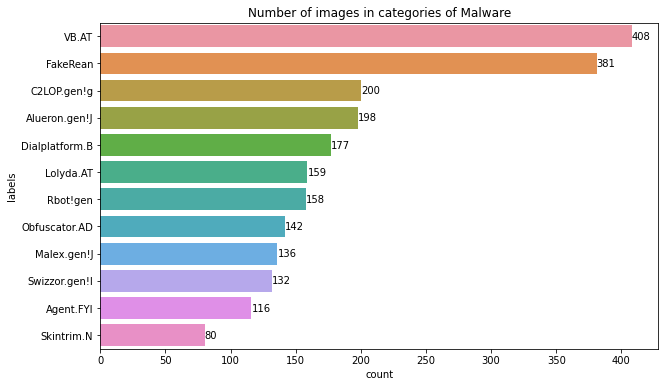

In [3]:
# Візуалізація кількості зображень у кожній категорії
label_counts = pd.DataFrame({"labels": labels})

plt.figure(figsize=(10, 6))
ax = sns.countplot(y="labels", data=label_counts,
                   order=label_counts["labels"].value_counts().index)
ax.set_title("Number of images in categories of Malware")
ax.bar_label(ax.containers[0])

plt.show()

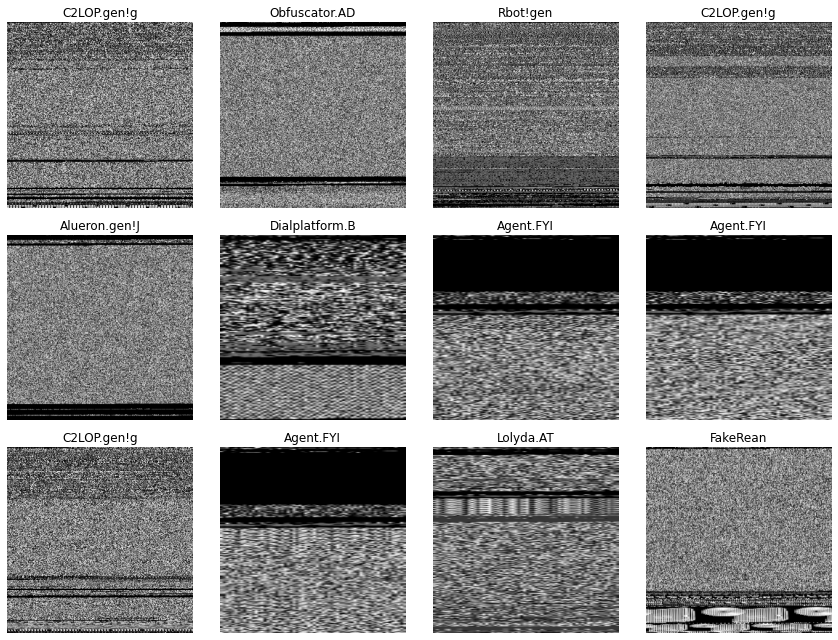

In [4]:
# Візуалізація деяких прикладів зображень
def visualize_samples(data, labels, num_samples=12):
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    for i, ax in enumerate(axes.ravel()):
        if i < len(data):
            rand_idx = np.random.randint(len(data))
            ax.imshow(data[rand_idx])
            ax.set_title(labels[rand_idx])
            ax.axis("off")
        else:
            ax.axis("off")
    plt.tight_layout()
    
    plt.show()


visualize_samples(images, labels)

### 3. Попередня обробка даних

In [5]:
image_size = (32, 32)

images, labels = zip(*[(np.array(PIL.Image.open(
    os.path.join(root, file)).convert('L').resize(image_size)).flatten(), os.path.basename(root))
    for root, _, files in os.walk(dataset_path) if files for file in files])
images, labels = np.array(images), list(labels)

In [6]:
encoded_labels = LabelEncoder().fit_transform(labels)
X_train, X_test, y_train, y_test = train_test_split(images, encoded_labels, test_size=0.2, random_state=42)

print(f"Number of images: {len(images)}")
print(f"Number of classes: {len(set(labels))}")
print(f"Train dataset size: {len(X_train)}")
print(f"Test dataset size: {len(X_test)}")

Number of images: 2287
Number of classes: 12
Train dataset size: 1829
Test dataset size: 458


### 4. Реалізація кластеризації

#### ◄► **Метод чутливого розташування хешувавання**

In [7]:
from datasketch import MinHash, MinHashLSH


# Створення MinHashLSH та додавання тренувальних даних
lsh, minhashes = MinHashLSH(threshold=0.8, num_perm=128), {}

for idx, image in enumerate(X_train):
    m = MinHash(num_perm=128)
    for pixel in image:
        m.update(str(pixel).encode('utf8'))
    minhashes[idx] = m
    lsh.insert(f"image_{idx}", m)

# Прогнозування на тестовому наборі даних
lsh_predictions = []
for image in X_test:
    m = MinHash(num_perm=128)
    for pixel in image:
        m.update(str(pixel).encode('utf8'))
    result = lsh.query(m)
    if result:
        predicted_label = np.bincount([y_train[int(r.split('_')[1])] for r in result]).argmax()
    else:
        predicted_label = np.bincount(y_train).argmax()  # Якщо немає збігів
    lsh_predictions.append(predicted_label)

print("Locality-Sensitive Hashing Classification Report:")
print(classification_report(y_test, lsh_predictions, zero_division=0))
print("Classification Accuracy:", accuracy_score(y_test, lsh_predictions))

Locality-Sensitive Hashing Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.57      0.71        21
           1       0.97      0.82      0.89        45
           2       0.89      0.87      0.88        46
           3       0.83      0.97      0.89        35
           4       0.91      0.99      0.95        71
           5       0.82      0.56      0.67        25
           6       1.00      0.81      0.89        31
           7       1.00      1.00      1.00        28
           8       0.72      0.84      0.78        31
           9       0.76      0.81      0.79        16
          10       0.67      0.39      0.49        31
          11       0.66      0.87      0.75        78

    accuracy                           0.83       458
   macro avg       0.85      0.79      0.81       458
weighted avg       0.84      0.83      0.82       458

Classification Accuracy: 0.8275109170305677


#### ◄► **Метод приблизних найближчих сусідів**

In [8]:
from sklearn.neighbors import NearestNeighbors


nn = NearestNeighbors(n_neighbors=5, algorithm='auto', metric='cosine')
nn.fit(X_train)

nn_predictions = []
for test_sample in X_test:
    distances, indices = nn.kneighbors([test_sample])
    nearest_labels = y_train[indices[0]]
    nn_predictions.append(np.bincount(nearest_labels).argmax())
nn_predictions = np.array(nn_predictions)

print("Nearest Neighbors Classification Report:")
print(classification_report(y_test, nn_predictions))
print("Classification Accuracy:", accuracy_score(y_test, nn_predictions))

Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        45
           2       0.88      1.00      0.94        46
           3       1.00      0.97      0.99        35
           4       1.00      0.99      0.99        71
           5       1.00      1.00      1.00        25
           6       0.88      0.97      0.92        31
           7       1.00      1.00      1.00        28
           8       0.97      1.00      0.98        31
           9       0.89      1.00      0.94        16
          10       1.00      0.84      0.91        31
          11       1.00      0.94      0.97        78

    accuracy                           0.97       458
   macro avg       0.97      0.97      0.97       458
weighted avg       0.97      0.97      0.97       458

Classification Accuracy: 0.9716157205240175


#### ◄► **Метод обчислення випадкового лісу дерев**

In [9]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_predictions = rf.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_predictions))
print("Classification Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       0.98      1.00      0.99        45
           2       1.00      1.00      1.00        46
           3       1.00      0.97      0.99        35
           4       1.00      1.00      1.00        71
           5       0.96      1.00      0.98        25
           6       1.00      0.97      0.98        31
           7       1.00      1.00      1.00        28
           8       1.00      1.00      1.00        31
           9       0.94      1.00      0.97        16
          10       1.00      1.00      1.00        31
          11       1.00      0.99      0.99        78

    accuracy                           0.99       458
   macro avg       0.99      0.99      0.99       458
weighted avg       0.99      0.99      0.99       458

Classification Accuracy: 0.9934497816593887


### 5. Побудова графіку точності моделей

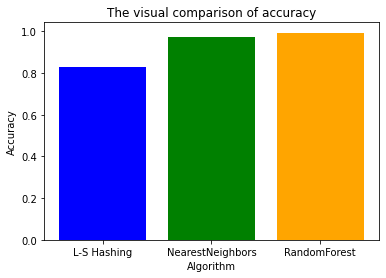

In [10]:
results = {
    "Algorithm": ["L-S Hashing", "NearestNeighbors", "RandomForest"],
    "Accuracy": [
        accuracy_score(y_test, lsh_predictions),
        accuracy_score(y_test, nn_predictions),
        accuracy_score(y_test, rf_predictions),
    ]
}

results_df = pd.DataFrame(results)
plt.bar(results_df["Algorithm"], results_df["Accuracy"], color=['blue', 'green', 'orange'])
plt.title("The visual comparison of accuracy")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")

plt.show()

<hr>

## Аналіз залежності точності моделі від розміру зображення

### Теоретичний аспект проблеми точності моделі на основі LSH

Зменшення розміру зображення може суттєво вплинути на точність моделі класифікації, зокрема в контексті таких методів, як LSH (Locality-Sensitive Hashing) та інших алгоритмів машинного навчання. Це залежить від кількох основних факторів:

1. **Зменшення розмірності зображення**: 
    Зменшення розміру зображення часто призводить до скорочення кількості пікселів, які потрібно обробляти під час навчання моделі. Це може зменшити обчислювальну складність і прискорити навчання, однак може мати як позитивний, так і негативний вплив на точність. 
    - **Позитивний вплив**: Якщо розмір зображення значно перевищує необхідний для представлення суттєвих ознак, зменшення може допомогти зберегти лише найважливіші характеристики, усуваючи зайві деталі.
    - **Негативний вплив**: Якщо зображення спрощуються занадто сильно, це може призвести до втрати важливих ознак, таких як текстури, форми, або інші специфічні деталі, що можуть вплинути на точність класифікації.

2. **Вплив на модель**: 
    Для таких методів, як LSH або логістична регресія, зменшення розміру зображення може мати різний ефект. Водночас це може зменшити шум, полегшити класифікацію і покращити точність, але також є ризик втратити важливі характеристики зображення, що можуть бути критичними для точності.

3. **Особливості даних**: 
    Датасети можуть мати різні рівні важливості для деталей зображення. Для зображень, що містять багато варіативних характеристик (наприклад, зображення з великим рівнем деталізації), зменшення розміру може бути корисним для збереження лише найважливіших ознак, але в той же час може призвести до втрати важливих внутрішніх відмінностей між класами.

4. **Зменшення шуму**: 
    При зменшенні розміру зображення зменшується кількість пікселів, що можуть бути сприйняті як шум. Це може бути корисно для поліпшення якості моделі, особливо якщо зображення містять багато непотрібних або незначущих деталей.

### Оптимізація розміру зображень для покращення класифікації

1. **Мінімізація перенавчання (Overfitting)**: 
    Коли модель тренується на великих зображеннях, вона може почати «запам'ятовувати» дрібні деталі, що не є важливими для класифікації. Зменшення розміру зображення дозволяє уникнути перенавчання, зберігаючи лише суттєві ознаки.
   
2. **Покращення загальної узагальненості**: 
    Менші зображення можуть покращити здатність моделі до узагальнення, оскільки вона зосереджується лише на важливих ознаках. Це допомагає точніше класифікувати нові зображення, зберігаючи критичні характеристики.
   
3. **Оптимізація ресурсів**: 
    Менші зображення зменшують обчислювальні витрати, що дозволяє моделі працювати швидше та ефективніше. Це дає можливість використовувати складніші моделі або покращити швидкість обробки без значних втрат у точності.

### Висновок

Зменшення розміру зображення може мати як позитивний, так і негативний вплив на точність моделі класифікації. Важливо збалансувати рівень деталізації зображень, щоб зберегти важливі ознаки і одночасно зменшити шум. Зменшення розміру може покращити точність, особливо при боротьбі з перенавчанням і зменшеннім обчислювальної складності, однак надмірне спрощення зображень може призвести до втрати критичних деталей.